# RoadSafe India — Road Infrastructure Data

## Objective

This notebook evaluates State/UT-level road infrastructure data as an
additional explanatory variable for the RoadSafe research dataset.

## Primary Variable

- Total road length (km)

## Potential Derived Variables

- Road length per 1,000 projected population
- Road length per 100 square kilometres

## Candidate Sources

- Reserve Bank of India — Handbook of Statistics on Indian States
- Ministry of Road Transport & Highways

## Research Question

Are differences in State/UT road infrastructure associated with differences
in reported accident and fatality burden?

## Important Limitation

Road length does not directly measure road quality, traffic volume,
congestion or vehicle-kilometres travelled.

In [35]:
from pathlib import Path
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt



In [2]:
project_root = Path.cwd().parent

road_data_path = (
    project_root
    / "data"
    / "research"
    / "road_infrastructure_source.xlsx"
)

print("File exists:", road_data_path.exists())

print("\nAvailable sheets:")
print(
    pd.ExcelFile(road_data_path).sheet_names
)

File exists: True

Available sheets:
['T_144(i)', 'T_143(ii)']


In [3]:
road_excel = pd.ExcelFile(road_data_path)

for sheet in road_excel.sheet_names:
    print("\n" + "=" * 60)
    print("SHEET:", sheet)
    print("=" * 60)

    preview = pd.read_excel(
        road_data_path,
        sheet_name=sheet,
        header=None,
        nrows=10
    )

    display(preview)


SHEET: T_144(i)


,0,1,2,3,4,5,6,7,8,9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,TABLE 143: STATE-WISE LENGTH OF ROADS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,(As at end-March),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,(Kms),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,State/Union Territory,2005.0,2006.0,2007.0,2008.0,2009.0,2010.0,2011.0,2012.0
5,NaN,Andaman & Nicobar Islands,1298.0,1301.0,1303.0,1301.0,1297.0,1302.0,1386.0,1319.0
6,NaN,Andhra Pradesh@,329407.0,336982.0,339002.0,345012.0,232280.0,235678.0,238001.0,256448.0
7,NaN,Arunachal Pradesh,17751.0,17216.0,17430.0,16494.0,20384.0,21122.0,21555.0,14980.0
8,NaN,Assam,208788.0,215819.0,223450.0,230334.0,236985.0,239394.0,241789.0,284232.0
9,NaN,Bihar,119958.0,120127.0,120127.0,120127.0,124363.0,128034.0,130642.0,138517.0



SHEET: T_143(ii)


,0,1,2,3,4,5,6,7,8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,TABLE 143: STATE-WISE LENGTH OF ROADS (Concld.),NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,(As at end-March),NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,(Kms),NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,State/Union Territory,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0
5,NaN,Andaman & Nicobar Islands,1388.0,1318.0,1352.0,1493.0,1617.0,1794.0,1809.0
6,NaN,Andhra Pradesh@,261657.0,178096.0,179022.0,174367.0,176474.0,218190.0,176351.0
7,NaN,Arunachal Pradesh,28095.0,24469.0,25362.0,30692.0,37025.0,50555.0,55262.0
8,NaN,Assam,288135.0,313621.0,326512.0,329520.0,337777.0,343609.0,399122.0
9,NaN,Bihar,197239.0,209758.0,206010.0,206484.0,209549.0,290571.0,298205.0


In [4]:
# Load Table 143(ii) — State-wise Length of Roads

road_table = pd.read_excel(
    road_data_path,
    sheet_name="T_143(ii)",
    header=None
)

print("Shape:", road_table.shape)

display(road_table.head(10))

Shape: (44, 9)


,0,1,2,3,4,5,6,7,8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,TABLE 143: STATE-WISE LENGTH OF ROADS (Concld.),NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,(As at end-March),NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,(Kms),NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,State/Union Territory,2013,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0
5,NaN,Andaman & Nicobar Islands,1388,1318.0,1352.0,1493.0,1617.0,1794.0,1809.0
6,NaN,Andhra Pradesh@,261657,178096.0,179022.0,174367.0,176474.0,218190.0,176351.0
7,NaN,Arunachal Pradesh,28095,24469.0,25362.0,30692.0,37025.0,50555.0,55262.0
8,NaN,Assam,288135,313621.0,326512.0,329520.0,337777.0,343609.0,399122.0
9,NaN,Bihar,197239,209758.0,206010.0,206484.0,209549.0,290571.0,298205.0


In [5]:
# Inspect the table header

for i in range(10):
    print(i, road_table.iloc[i].tolist())

0 [np.float64(nan), nan, nan, np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]
1 [np.float64(nan), 'TABLE 143: STATE-WISE LENGTH OF ROADS (Concld.)', nan, np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]
2 [np.float64(nan), '(As at end-March)', nan, np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]
3 [np.float64(nan), '(Kms)', nan, np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]
4 [np.float64(nan), 'State/Union Territory', 2013, np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0)]
5 [np.float64(nan), 'Andaman & Nicobar Islands', 1388, np.float64(1318.0), np.float64(1352.0), np.float64(1493.0), np.float64(1617.0), np.float64(1794.0), np.float64(1809.0)]
6 [np.float64(nan), 'Andhra Pradesh@', 261657, np.float64(17

In [6]:
# Extract 2019 State/UT road length

road_2019 = road_table.iloc[5:].copy()

# Column 1 = State/Union Territory
# Column 8 = 2019 road length (kms)

road_2019 = road_2019.iloc[:, [1, 8]].copy()

road_2019.columns = [
    "state",
    "road_length_2019_km"
]

# Clean State/UT names
road_2019["state"] = (
    road_2019["state"]
    .astype("string")
    .str.strip()
)

# Convert road length to numeric
road_2019["road_length_2019_km"] = pd.to_numeric(
    road_2019["road_length_2019_km"],
    errors="coerce"
)

# Remove invalid rows
road_2019 = road_2019[
    road_2019["state"].notna()
    & road_2019["road_length_2019_km"].notna()
].copy()

# Remove aggregate rows
road_2019 = road_2019[
    ~road_2019["state"].str.lower().isin(
        ["total", "all india", "india"]
    )
].copy()

# Reset index
road_2019 = road_2019.reset_index(drop=True)

print("Road infrastructure dataset shape:")
print(road_2019.shape)

print("\nUnique State/UTs:")
print(road_2019["state"].nunique())

display(road_2019.head(10))

Road infrastructure dataset shape:
(36, 2)

Unique State/UTs:
36


,state,road_length_2019_km
0,Andaman & Nicobar Islands,1809.0
1,Andhra Pradesh@,176351.0
2,Arunachal Pradesh,55262.0
3,Assam,399122.0
4,Bihar,298205.0
5,Chandigarh,2573.0
6,Chhattisgarh,105074.0
7,Dadra & Nagar Haveli,1133.0
8,Daman & Diu,274.0
9,Delhi,16170.0


In [7]:
# Check duplicate State/UTs

print(
    "Duplicate State/UT rows:",
    road_2019["state"].duplicated().sum()
)

print("\nDuplicate entries:")

display(
    road_2019[
        road_2019["state"].duplicated(
            keep=False
        )
    ]
)

Duplicate State/UT rows: 0

Duplicate entries:


,state,road_length_2019_km


In [8]:
# List State/UT names

for i, state in enumerate(
    road_2019["state"],
    start=1
):
    print(i, state)

1 Andaman & Nicobar Islands
2 Andhra Pradesh@
3 Arunachal Pradesh
4 Assam
5 Bihar
6 Chandigarh
7 Chhattisgarh
8 Dadra & Nagar Haveli
9 Daman & Diu
10 Delhi
11 Goa
12 Gujarat
13 Haryana
14 Himachal Pradesh
15 Jammu & Kashmir
16 Jharkhand
17 Karnataka
18 Kerala
19 Lakshadweep
20 Madhya Pradesh
21 Maharashtra
22 Manipur
23 Meghalaya
24 Mizoram
25 Nagaland
26 Odisha
27 Puducherry
28 Punjab
29 Rajasthan
30 Sikkim
31 Tamil Nadu
32 Telangana@
33 Tripura
34 Uttar Pradesh
35 Uttarakhand
36 West Bengal


## Road Infrastructure Reference Year

Table 143: State-wise Length of Roads reports road length as at
the end of March.

For this research analysis, the 2019 observation is used because
2019 is the latest year available in the supplied Table 143 workbook.

Therefore, the variable is explicitly named:

`road_length_2019_km`

It should not be interpreted as 2024 road length.

In [9]:
# Load RoadSafe research dataset

research_path = (
    project_root
    / "data"
    / "research"
    / "vehicle_exposure_2024_state_level.csv"
)

research_df = pd.read_csv(research_path)

print("Research dataset shape:", research_df.shape)

Research dataset shape: (36, 28)


In [10]:
# Compare State/UT names

roadsafe_states = set(
    research_df["state"].dropna()
)

road_states = set(
    road_2019["state"].dropna()
)

print("States only in RoadSafe research dataset:")
print(
    sorted(
        roadsafe_states - road_states
    )
)

print("\nStates only in road infrastructure dataset:")
print(
    sorted(
        road_states - roadsafe_states
    )
)

States only in RoadSafe research dataset:
['Andhra Pradesh', 'Dadra & Nagar Haveli and Daman & Diu', 'Ladakh', 'N.C.T of Delhi', 'Telangana']

States only in road infrastructure dataset:
['Andhra Pradesh@', 'Dadra & Nagar Haveli', 'Daman & Diu', 'Delhi', 'Telangana@']


In [11]:
# Display the full extracted road dataset

display(
    road_2019.sort_values("state")
)

,state,road_length_2019_km
0,Andaman & Nicobar Islands,1809.0
1,Andhra Pradesh@,176351.0
2,Arunachal Pradesh,55262.0
3,Assam,399122.0
4,Bihar,298205.0
5,Chandigarh,2573.0
6,Chhattisgarh,105074.0
7,Dadra & Nagar Haveli,1133.0
8,Daman & Diu,274.0
9,Delhi,16170.0


In [12]:
# Inspect State/UT naming differences

mismatch_names = [
    "Andhra Pradesh@",
    "Dadra & Nagar Haveli",
    "Daman & Diu",
    "Delhi",
    "Telangana@"
]

display(
    road_2019[
        road_2019["state"].isin(mismatch_names)
    ].sort_values("state")
)

,state,road_length_2019_km
1,Andhra Pradesh@,176351.0
7,Dadra & Nagar Haveli,1133.0
8,Daman & Diu,274.0
9,Delhi,16170.0
31,Telangana@,140555.0


In [13]:
# Investigate Jammu, Kashmir and Ladakh

display(
    road_2019[
        road_2019["state"]
        .str.contains(
            "Jammu|Kashmir|Ladakh",
            case=False,
            na=False
        )
    ]
)

,state,road_length_2019_km
14,Jammu & Kashmir,120034.0


In [14]:
# Standardize RBI State/UT names

road_name_mapping = {

    # Remove source footnote markers
    "Andhra Pradesh@":
        "Andhra Pradesh",

    "Telangana@":
        "Telangana",

    # Delhi naming
    "Delhi":
        "N.C.T of Delhi"
}


road_2019["state_standardized"] = (
    road_2019["state"]
    .replace(road_name_mapping)
)

In [15]:
# Combine Dadra & Nagar Haveli and Daman & Diu

dnhdd_mask = road_2019["state_standardized"].isin(
    [
        "Dadra & Nagar Haveli",
        "Daman & Diu"
    ]
)

dnhdd_total = (
    road_2019.loc[
        dnhdd_mask,
        "road_length_2019_km"
    ]
    .sum()
)

print(
    "Combined DNHDD road length:",
    dnhdd_total
)

Combined DNHDD road length: 1407.0


In [16]:
# Remove the two separate UT components
road_2019 = road_2019[
    ~dnhdd_mask
].copy()


# Add the combined Union Territory
dnhdd_row = pd.DataFrame({
    "state": [
        "Dadra & Nagar Haveli and Daman & Diu"
    ],
    "road_length_2019_km": [
        dnhdd_total
    ],
    "state_standardized": [
        "Dadra & Nagar Haveli and Daman & Diu"
    ]
})


road_2019 = pd.concat(
    [
        road_2019,
        dnhdd_row
    ],
    ignore_index=True
)

In [17]:
# Validate standardized road dataset

print(
    "Rows:",
    len(road_2019)
)

print(
    "Unique States/UTs:",
    road_2019["state_standardized"].nunique()
)

print(
    "Duplicate standardized States/UTs:",
    road_2019[
        "state_standardized"
    ].duplicated().sum()
)

Rows: 35
Unique States/UTs: 35
Duplicate standardized States/UTs: 0


In [18]:
# Compare standardized road data with RoadSafe

roadsafe_states = set(
    research_df["state"].dropna()
)

road_states = set(
    road_2019["state_standardized"].dropna()
)


print("States only in RoadSafe:")
print(
    sorted(
        roadsafe_states - road_states
    )
)


print("\nStates only in RBI road data:")
print(
    sorted(
        road_states - roadsafe_states
    )
)

States only in RoadSafe:
['Ladakh']

States only in RBI road data:
[]


## Ladakh Coverage Limitation

The supplied RBI Table 143 reports 2019 State/UT road length for
Jammu & Kashmir but does not provide a separate Ladakh observation.

Because Ladakh became a separate Union Territory in 2019, the available
table does not provide a directly comparable standalone road-length value
for Ladakh.

The RoadSafe research dataset therefore does not impute or artificially
partition the Jammu & Kashmir road-length value to estimate Ladakh's
2019 road length.

Ladakh will remain missing for this specific infrastructure variable
unless a reliable source providing a separate Ladakh road-length
observation is identified.

In [19]:
# Prepare final road infrastructure dataset

road_final = road_2019[
    [
        "state_standardized",
        "road_length_2019_km"
    ]
].copy()

In [20]:
# Merge road infrastructure into research dataset

research_df = research_df.merge(
    road_final,
    left_on="state",
    right_on="state_standardized",
    how="left",
    validate="one_to_one"
)


research_df = research_df.drop(
    columns=["state_standardized"]
)

In [21]:
print(
    "Research dataset shape:",
    research_df.shape
)

print(
    "Missing road-length values:",
    research_df[
        "road_length_2019_km"
    ].isna().sum()
)


print("\nStates with missing road length:")

display(
    research_df[
        research_df["road_length_2019_km"].isna()
    ][
        ["state"]
    ]
)

Research dataset shape: (36, 29)
Missing road-length values: 1

States with missing road length:


,state
33,Ladakh


In [22]:
research_df[
    "road_length_per_1000_population"
] = (
    research_df["road_length_2019_km"]
    / research_df["population_2024"]
    * 1000
)

In [23]:
# Save research dataset with road infrastructure

research_output_path = (
    project_root
    / "data"
    / "research"
    / "road_infrastructure_2019_state_level.csv"
)

research_df.to_csv(
    research_output_path,
    index=False
)

print(
    "Saved to:"
)

print(research_output_path)

Saved to:
d:\Data Science\Projects\RoadSafe-India\data\research\road_infrastructure_2019_state_level.csv


In [24]:
# Load research dataset

research_path = (
    project_root
    / "data"
    / "research"
    / "road_infrastructure_2019_state_level.csv"
)

research_df = pd.read_csv(research_path)

print("Shape:", research_df.shape)

display(research_df.head())

Shape: (36, 30)


,state,2020_accidents,2021_accidents,2022_accidents,2023_accidents,2024_accidents,2020_killed,2021_killed,2022_killed,2023_killed,...,fatality_change_2020_to_2024,fatality_percent_change_2020_to_2024,accident_rank_2024,fatality_rank_2024,accident_rate_rank_2024,fatality_rate_rank_2024,vehicle_registrations_2024,vehicles_per_1000_population,road_length_2019_km,road_length_per_1000_population
0,Andhra Pradesh,19509.0,21556.0,21249.0,19949.0,19557.0,7039.0,8186,8293,8137,...,1307.0,18.567978,9.0,8.0,11.0,8.0,911747,17.093120,176351.0,3.306168
1,Arunachal Pradesh,134.0,283.0,227.0,287.0,277.0,73.0,157,148,145,...,95.0,130.136986,27.0,27.0,24.0,18.0,36796,23.347716,55262.0,35.064721
2,Assam,6595.0,7411.0,7023.0,7421.0,7848.0,2629.0,3036,2994,3296,...,722.0,27.462914,16.0,18.0,19.0,22.0,629458,17.462147,399122.0,11.072267
3,Bihar,8639.0,9553.0,10801.0,11014.0,11610.0,6699.0,7660,8898,8873,...,2648.0,39.528288,14.0,7.0,33.0,25.0,1395212,10.849913,298205.0,2.319001
4,Chhattisgarh,11656.0,12375.0,13279.0,13468.0,14857.0,4606.0,5371,5834,6166,...,2339.0,50.781589,11.0,11.0,9.0,2.0,714000,23.391430,105074.0,3.442340


In [25]:
# Validate road infrastructure variables

required_columns = [
    "state",
    "2024_accidents",
    "2024_killed",
    "population_2024",
    "road_length_2019_km",
    "road_length_per_1000_population"
]

missing_columns = [
    column
    for column in required_columns
    if column not in research_df.columns
]

print("Missing required columns:")
print(missing_columns)

print("\nMissing road-length values:")
print(
    research_df[
        "road_length_2019_km"
    ].isna().sum()
)

print("\nStates with missing road length:")

display(
    research_df[
        research_df["road_length_2019_km"].isna()
    ][["state"]]
)

Missing required columns:
[]

Missing road-length values:
1

States with missing road length:


,state
33,Ladakh


In [26]:
# Road infrastructure descriptive statistics

road_summary = (
    research_df[
        [
            "road_length_2019_km",
            "road_length_per_1000_population"
        ]
    ]
    .describe()
    .T
)

display(road_summary)

,count,mean,std,min,25%,50%,75%,max
road_length_2019_km,35.0,155193.057143,160131.578891,232.00000,25543.000000,81245.000000,277501.000000,636887.000000
road_length_per_1000_population,35.0,6.908385,6.595198,0.74338,3.078639,4.477723,9.857075,35.064721


In [27]:
# Largest road networks

top_road_states = (
    research_df[
        [
            "state",
            "road_length_2019_km"
        ]
    ]
    .dropna()
    .sort_values(
        "road_length_2019_km",
        ascending=False
    )
    .head(10)
)

display(top_road_states)

,state,road_length_2019_km
13,Maharashtra,636887.0
26,Uttar Pradesh,442907.0
2,Assam,399122.0
12,Madhya Pradesh,365045.0
10,Karnataka,358300.0
20,Rajasthan,313469.0
18,Odisha,305631.0
3,Bihar,298205.0
27,West Bengal,283865.0
22,Tamil Nadu,271137.0


In [28]:
# Road length per 1,000 population

top_road_rate_states = (
    research_df[
        [
            "state",
            "road_length_per_1000_population"
        ]
    ]
    .dropna()
    .sort_values(
        "road_length_per_1000_population",
        ascending=False
    )
    .head(10)
)

display(top_road_rate_states)

,state,road_length_per_1000_population
1,Arunachal Pradesh,35.064721
21,Sikkim,17.528058
17,Nagaland,16.809143
16,Mizoram,13.000000
15,Meghalaya,11.914176
5,Goa,11.811118
2,Assam,11.072267
24,Tripura,10.783939
14,Manipur,9.956655
8,Himachal Pradesh,9.757495


In [29]:
# Road length vs accidents

road_complete = research_df.dropna(
    subset=[
        "road_length_2019_km",
        "2024_accidents"
    ]
).copy()


road_accident_corr = (
    road_complete[
        [
            "road_length_2019_km",
            "2024_accidents"
        ]
    ]
    .corr()
    .loc[
        "road_length_2019_km",
        "2024_accidents"
    ]
)

print(
    "Road length vs reported accidents:"
)

print(
    f"Pearson r = {road_accident_corr:.4f}"
)

Road length vs reported accidents:
Pearson r = 0.7218


In [30]:
# Road length vs fatalities

road_fatality_corr = (
    road_complete[
        [
            "road_length_2019_km",
            "2024_killed"
        ]
    ]
    .corr()
    .loc[
        "road_length_2019_km",
        "2024_killed"
    ]
)

print(
    "Road length vs reported fatalities:"
)

print(
    f"Pearson r = {road_fatality_corr:.4f}"
)

Road length vs reported fatalities:
Pearson r = 0.8199


In [31]:
# Normalized road infrastructure vs accident burden

road_rate_accident_rate_corr = (
    road_complete[
        [
            "road_length_per_1000_population",
            "accidents_per_100k_population"
        ]
    ]
    .corr()
    .loc[
        "road_length_per_1000_population",
        "accidents_per_100k_population"
    ]
)

print(
    "Road length per 1,000 population vs "
    "accidents per 100k population:"
)

print(
    f"Pearson r = {road_rate_accident_rate_corr:.4f}"
)

Road length per 1,000 population vs accidents per 100k population:
Pearson r = -0.0566


In [32]:
# Normalized road infrastructure vs fatality burden

road_rate_fatality_rate_corr = (
    road_complete[
        [
            "road_length_per_1000_population",
            "fatalities_per_100k_population"
        ]
    ]
    .corr()
    .loc[
        "road_length_per_1000_population",
        "fatalities_per_100k_population"
    ]
)

print(
    "Road length per 1,000 population vs "
    "fatalities per 100k population:"
)

print(
    f"Pearson r = {road_rate_fatality_rate_corr:.4f}"
)

Road length per 1,000 population vs fatalities per 100k population:
Pearson r = -0.1759


In [33]:
road_accident_spearman = stats.spearmanr(
    road_complete[
        "road_length_per_1000_population"
    ],
    road_complete[
        "accidents_per_100k_population"
    ]
)

print(
    "Road length/1,000 vs accidents/100k"
)

print(
    f"Spearman rho = "
    f"{road_accident_spearman.statistic:.4f}"
)

print(
    f"p-value = "
    f"{road_accident_spearman.pvalue:.6f}"
)

Road length/1,000 vs accidents/100k
Spearman rho = -0.0454
p-value = 0.795755


In [34]:
road_fatality_spearman = stats.spearmanr(
    road_complete[
        "road_length_per_1000_population"
    ],
    road_complete[
        "fatalities_per_100k_population"
    ]
)

print(
    "Road length/1,000 vs fatalities/100k"
)

print(
    f"Spearman rho = "
    f"{road_fatality_spearman.statistic:.4f}"
)

print(
    f"p-value = "
    f"{road_fatality_spearman.pvalue:.6f}"
)

Road length/1,000 vs fatalities/100k
Spearman rho = -0.1129
p-value = 0.518505


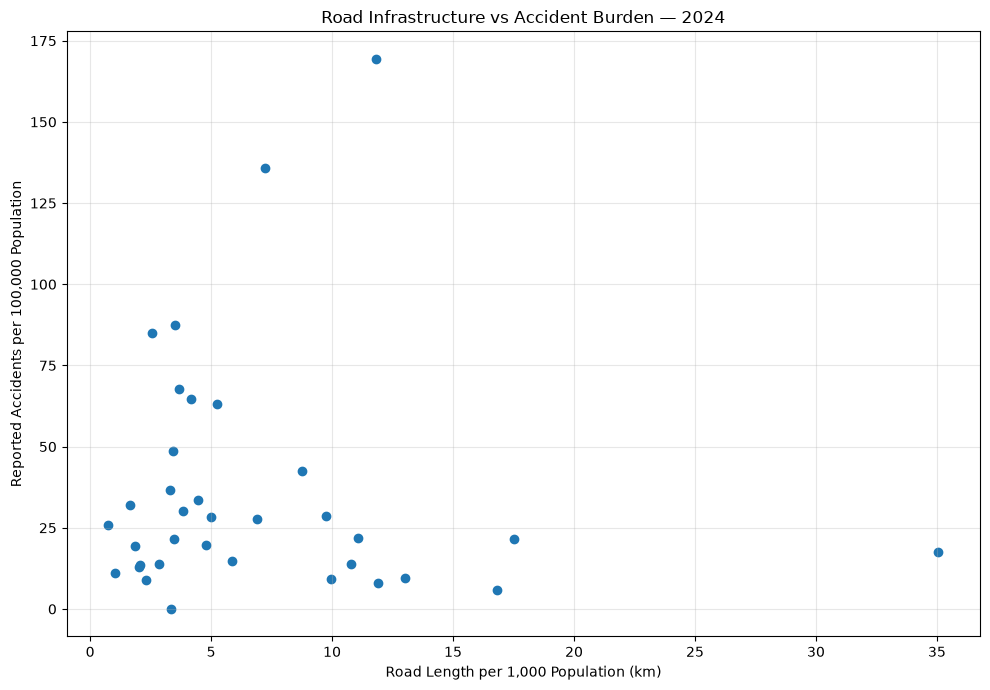

In [36]:
plt.figure(figsize=(10, 7))

plt.scatter(
    road_complete[
        "road_length_per_1000_population"
    ],
    road_complete[
        "accidents_per_100k_population"
    ]
)

plt.title(
    "Road Infrastructure vs Accident Burden — 2024"
)

plt.xlabel(
    "Road Length per 1,000 Population (km)"
)

plt.ylabel(
    "Reported Accidents per 100,000 Population"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

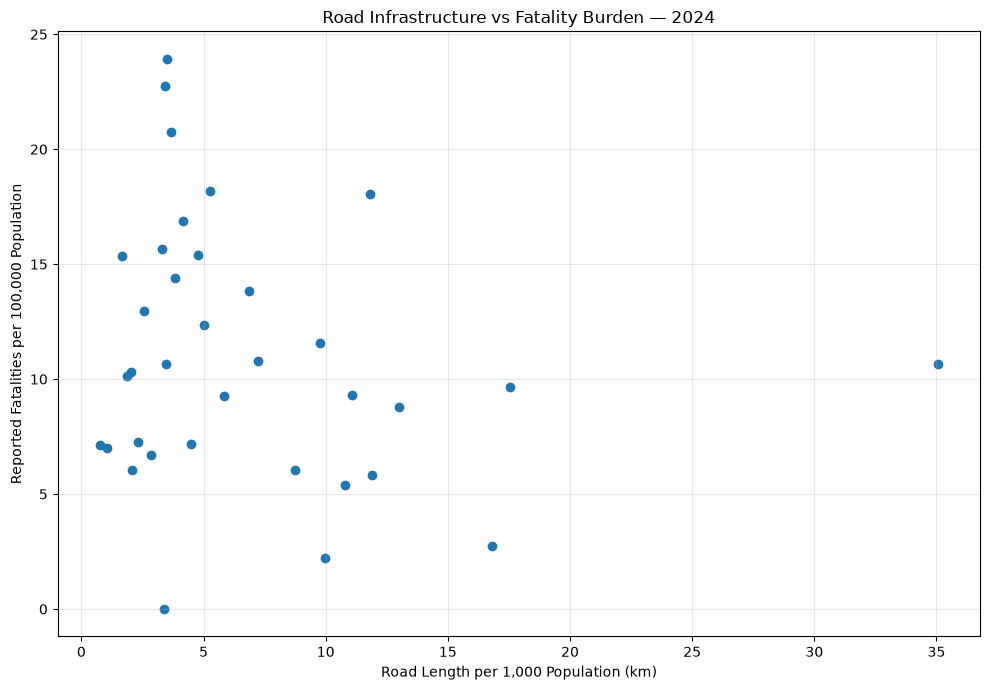

In [37]:
plt.figure(figsize=(10, 7))

plt.scatter(
    road_complete[
        "road_length_per_1000_population"
    ],
    road_complete[
        "fatalities_per_100k_population"
    ]
)

plt.title(
    "Road Infrastructure vs Fatality Burden — 2024"
)

plt.xlabel(
    "Road Length per 1,000 Population (km)"
)

plt.ylabel(
    "Reported Fatalities per 100,000 Population"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [38]:
road_correlations = pd.DataFrame({

    "relationship": [
        "Road length vs accidents",
        "Road length vs fatalities",
        "Road length/1000 vs accidents/100k",
        "Road length/1000 vs fatalities/100k"
    ],

    "pearson_r": [
        road_accident_corr,
        road_fatality_corr,
        road_rate_accident_rate_corr,
        road_rate_fatality_rate_corr
    ],

    "spearman_rho": [
        None,
        None,
        road_accident_spearman.statistic,
        road_fatality_spearman.statistic
    ],

    "spearman_p_value": [
        None,
        None,
        road_accident_spearman.pvalue,
        road_fatality_spearman.pvalue
    ]
})

display(road_correlations)

,relationship,pearson_r,spearman_rho,spearman_p_value
0,Road length vs accidents,0.721774,NaN,NaN
1,Road length vs fatalities,0.819856,NaN,NaN
2,Road length/1000 vs accidents/100k,-0.056648,-0.045378,0.795755
3,Road length/1000 vs fatalities/100k,-0.175943,-0.112885,0.518505


In [39]:
road_results_path = (
    project_root
    / "data"
    / "research"
    / "road_infrastructure_correlations_2024.csv"
)

road_correlations.to_csv(
    road_results_path,
    index=False
)

print(
    "Results saved to:",
    road_results_path
)

Results saved to: d:\Data Science\Projects\RoadSafe-India\data\research\road_infrastructure_correlations_2024.csv


## Road Infrastructure — Preliminary Findings

Road length has a strong positive raw association with reported accidents
(Pearson r = 0.7218) and reported fatalities (Pearson r = 0.8199) across the
State/UT observations.

However, these relationships are substantially different after population
normalization.

Road length per 1,000 population has essentially no monotonic relationship
with reported accidents per 100,000 population (Spearman rho = -0.0454,
p = 0.795755).

Similarly, road length per 1,000 population has a weak negative but
statistically non-significant relationship with reported fatalities per
100,000 population (Spearman rho = -0.1129, p = 0.518505).

These results suggest that the strong raw association between road length
and accident/fatality counts is substantially related to differences in
State/UT size. Within the current dataset, population-normalized road
length alone does not provide evidence of a meaningful association with
population-normalized accident or fatality burden.

The road-length observations are from 2019, while the road-safety outcomes
are from 2024. Therefore, these results should be interpreted as an
exploratory cross-sectional association involving a lagged infrastructure
indicator rather than a same-year causal relationship.